In [24]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import gc

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset

In [25]:
# Global variables
AA_VOCAB = list('ACDEFGHIKLMNPQRSTVWXY')
SS8_VOCAB = ['C', 'B', 'E', 'G', 'I', 'H', 'S', 'T']
NUM_CLASSES = len(SS8_VOCAB)
MAX_LEN = 700
REPLACEMENT_DICT = {
    ("A","V"), ("S","T"), ("F","Y"), ("K","R"), ("C","M"), ("D","E"), ("N","Q"), ("L","I"),
    ("V","A"), ("T","S"), ("Y","F"), ("R","K"), ("M","C"), ("E","D"), ("Q","N"), ("I","L")
} # no replacement for G, H, P, W, X
SAVE_DIR = "/home/ec2-user/SageMaker/"

In [26]:
class ProteinDataset(Dataset):
    def __init__(self, df, embeddings, max_len=MAX_LEN):
        self.df = df.reset_index(drop=True)
        self.embeddings = embeddings  # (N, 700, 320)
        self.ss_map = {c: i for i, c in enumerate(SS8_VOCAB)}
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def encode_labels(self, seq):
        arr = np.zeros(self.max_len, dtype=np.int64)
        for i, ch in enumerate(seq[:self.max_len]):
            if ch in self.ss_map:
                arr[i] = self.ss_map[ch]
        return arr

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        X = self.embeddings[idx].astype(np.float32)  # (700, 320)
        y = self.encode_labels(row['dssp8'])          # (700,)
        length = min(len(row['input']), self.max_len)
        mask = np.zeros(self.max_len, dtype=np.float32)
        mask[:length] = 1.0
        return (torch.tensor(X),
                torch.tensor(y),
                torch.tensor(mask))

In [27]:
class ProteinModel(nn.Module):
    def __init__(self, AA_size, dim_model, dim_out, batch_size, dropout):
        super().__init__()
        self.AA_size = AA_size
        self.dim_model = dim_model
        self.dim_out = dim_out
        self.batch_size = batch_size
        
        # No embedding layer since the data is already embedded
        self.LSTM = torch.nn.LSTM(input_size=320, hidden_size=dim_model, batch_first=True)
        self.drop = torch.nn.Dropout(dropout)
        self.lin = torch.nn.Linear(dim_model, dim_out)
    
    def forward(self, input):
        x, _ = self.LSTM(input)
        x = self.lin(x)
        return x

In [28]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False     # don't stop
        self.counter += 1
        return self.counter >= self.patience  # stop if patience exceeded

In [29]:
def train(data_loader, model, criterion, optimizer, device):
    train_avg_loss = 0
    num_correct = 0
    total_residues = 0

    model.train()  # Set model to training mode

    # Implement training loop
    for X, y, mask in tqdm(data_loader, leave=False):
        optimizer.zero_grad()
        X = X.to(device=device, dtype=torch.float32)
        y = y.to(device=device, dtype=torch.long)
        mask = mask.to(device=device, dtype=torch.long)

        # Perform forward pass
        y_hat = model.forward(X)
        pred = y_hat.argmax(dim=-1).to(dtype=torch.long)

        # Calculate loss at every position and ignore padding
        loss = criterion(y_hat.reshape(-1, NUM_CLASSES), y.reshape(-1))
        loss = (loss * mask.reshape(-1)).sum() / mask.sum()

        # Calculate number of correct predictions (ignore masked values)
        corr = torch.sum((y == pred) * mask)
        total_residues += mask.sum().item()

        # Backward pass, update weights, and zero gradients
        loss.backward()
        optimizer.step()

        num_correct += corr.item()
        train_avg_loss += loss.item()


    # print the loss and accuracy at the end of each epoch
    final_loss = train_avg_loss/len(data_loader)
    final_acc = num_correct/total_residues
    print(f"Train loss: {final_loss} | Accuracy: {final_acc}")

    return final_loss, final_acc

In [30]:
def test(data_loader, model, criterion, device):
    test_avg_loss = 0
    num_correct = 0
    total_residues = 0

    model.eval() # Set model to eval mode

    # Implement testing loop
    with torch.no_grad():
        for X, y, mask in tqdm(data_loader, leave=False):
            X = X.to(device=device, dtype=torch.float32)
            y = y.to(device=device, dtype=torch.long)
            mask = mask.to(device=device, dtype=torch.long)
    
            # Perform forward pass
            y_hat = model.forward(X)
            pred = y_hat.argmax(dim=-1).to(dtype=torch.long)
    
            # Calculate loss at every position and ignore padding
            loss = criterion(y_hat.reshape(-1, NUM_CLASSES), y.reshape(-1))
            loss = (loss * mask.reshape(-1)).sum() / mask.sum()
    
            # Calculate number of correct predictions (ignore masked values)
            corr = torch.sum((y == pred) * mask)
            total_residues += mask.sum().item()
    
            num_correct += corr.item()
            test_avg_loss += loss.item()

    # print the loss and accuracy at the end of each epoch
    final_loss = test_avg_loss/len(data_loader)
    final_acc = num_correct/total_residues
    print(f"Test loss: {final_loss} | Accuracy: {final_acc}")

    return final_loss, final_acc

In [31]:
def run(num_epochs, train_dataloader, test_dataloader, model, criterion, optimizer, device):
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    
    early_stopping = EarlyStopping(patience=5, min_delta=0.001)
    BEST_MODEL_PATH = "/home/ec2-user/SageMaker/best_model.pt"
    best_test_loss = float("inf")
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        train_loss, train_acc = train(train_dataloader, model, criterion, optimizer, device)
        test_loss, test_acc = test(test_dataloader, model, criterion, device)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        # Early stopping
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            torch.save(model.state_dict(), BEST_MODEL_PATH)
        if early_stopping.step(test_loss): break

    model.load_state_dict(torch.load(BEST_MODEL_PATH))
    return train_losses, train_accs, test_losses, test_accs

In [32]:
def plot_over_epoch(train_res, val_res, title, ylabel):
    epochs = range(1, len(train_res) + 1)
    plt.figure(figsize=(10, 6))
    
    plt.plot(epochs, train_res, label='Train', color='blue')
    plt.plot(epochs, val_res, label='Validation', color='red')
    
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    
    # save_path = DRIVE_PATH + "/Plots/LSTMwPLM/" + title + ".png"
    # plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

In [33]:
def plot_confusion_matrix(data_loader, model, title, as_percent = True, class_names=SS8_VOCAB):
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for X, y, mask in tqdm(data_loader, leave=False):
            X = X.to(device=device, dtype=torch.float32)
            y = y.to(device=device, dtype=torch.long)
            mask = mask.to(device=device, dtype=torch.bool)

            y_hat = model.forward(X)
            pred = y_hat.argmax(dim=-1).to(dtype=torch.long)

            all_preds.append(pred[mask].cpu())
            all_labels.append(y[mask].cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    fig, ax = plt.subplots(figsize=(10, 8))

    cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(class_names))))
    if as_percent:
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    else:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()

    # save_path = DRIVE_PATH + "/Plots/LSTMwPLM/" + title + ".png"
    # fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(classification_report(all_labels, all_preds, target_names=class_names))
    plt.close()

    return cm

In [34]:
def experiment(
    train_loader,
    val_loader,
    # Hyperparameters
    weighted_loss = False,
    AA_size = len(AA_VOCAB),
    batch_size = 32,
    dim_model = 128,
    dropout=0.3,
    max_len = MAX_LEN,
    lr = 1e-4,
    decay = 1e-5,
    num_epochs = 50,
    num_classes = NUM_CLASSES
):
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

    # Initialize model
    model = ProteinModel(AA_size=AA_size, dim_model=dim_model, dim_out=num_classes, batch_size=batch_size, dropout=dropout)
    model.to(device)

    # Initialize loss function and optimizer
    if weighted_loss:
        # Calculate inverse frequency weights
        all_labels = ''.join(df_train['dssp8'].tolist())
        counts = Counter(all_labels)
        freqs = np.array([counts[c] for c in SS8_VOCAB], dtype=np.float32)
        weights = 1.0 / freqs
        weights = weights / weights.sum() * len(SS8_VOCAB)  # normalise
        
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights).to(device), reduction='none')
    else:
        criterion = torch.nn.CrossEntropyLoss(reduction='none').to(device=device)

    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=decay)

    # Run training and validation
    train_losses, train_accs, val_losses, val_accs = run(num_epochs=num_epochs, train_dataloader=train_loader,
                                                           test_dataloader=val_loader, model=model,
                                                            criterion=criterion, optimizer=optim, device=device)

    plot_name = f'_{"weighted" if weighted_loss else "unweighted"}'
    plot_over_epoch(train_losses, val_losses, "loss" + plot_name, "Loss")
    plot_over_epoch(train_accs, val_accs, "acc" + plot_name, "Accuracy")
    plot_confusion_matrix(val_loader, model, "cm" + plot_name)

    return train_losses, train_accs, val_losses, val_accs, model

In [35]:
train_df = pd.read_csv(SAVE_DIR + "training_hhblits.csv")
test_df = pd.read_csv(SAVE_DIR + "CB513.csv")

indices = np.arange(len(train_df))
train_idx, val_idx = train_test_split(indices, test_size=0.1, random_state=42)
train_idx_sorted = np.sort(train_idx)
val_idx_sorted = np.sort(val_idx)


df_train = train_df.iloc[train_idx_sorted].reset_index(drop=True)
df_val = train_df.iloc[val_idx_sorted].reset_index(drop=True)
del train_df
gc.collect()

57099

In [36]:
train_embeddings = np.load(SAVE_DIR + "embeddings/train_embeddings.npy", mmap_mode='r')
test_embeddings = np.load(SAVE_DIR + "embeddings/test_embeddings.npy",  mmap_mode='r')

emb_train = train_embeddings[train_idx_sorted]
emb_val = train_embeddings[val_idx_sorted].copy()

In [37]:
train_dataset = ProteinDataset(df_train, emb_train)
val_dataset = ProteinDataset(df_val,   emb_val)
test_dataset = ProteinDataset(test_df,  test_embeddings)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

In [38]:
X_batch, y_batch, mask_batch = next(iter(train_loader))
print(f"X:          {X_batch.shape}")     # (32, 700, 320)
print(f"y:          {y_batch.shape}")     # (32, 700)
print(f"mask:       {mask_batch.shape}")  # (32, 700)
print(f"Train:      {len(train_dataset)} proteins")
print(f"Validation: {len(val_dataset)} proteins")
print(f"Test:       {len(test_dataset)} proteins")

X:          torch.Size([32, 700, 320])
y:          torch.Size([32, 700])
mask:       torch.Size([32, 700])
Train:      9712 proteins
Validation: 1080 proteins
Test:       511 proteins


Epoch 0


Train loss: 1.4544138767217334 | Accuracy: 0.4978842873562377


Test loss: 1.1786206399693209 | Accuracy: 0.5967774413294479
Epoch 1


Train loss: 1.1166767101538808 | Accuracy: 0.6149496531971989


Test loss: 1.0832195965682758 | Accuracy: 0.6250251703032215
Epoch 2


...

Test loss: 0.9644287316238179 | Accuracy: 0.6607385061947441
Epoch 48


Train loss: 0.9256669224092835 | Accuracy: 0.6708842637669772


Test loss: 0.9622237331726972 | Accuracy: 0.6611146360089207
Epoch 49


Train loss: 0.9243249285377955 | Accuracy: 0.6712799939481345


Test loss: 0.9630017000086167 | Accuracy: 0.6607233090305349


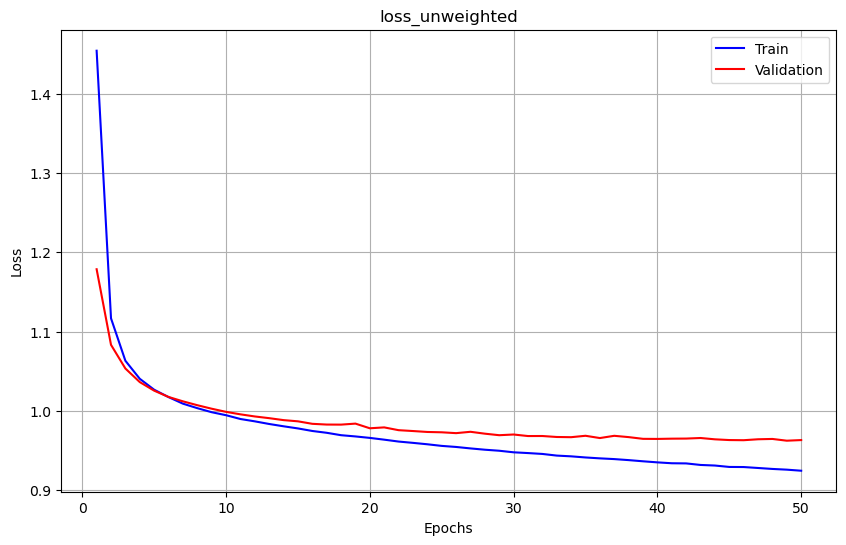

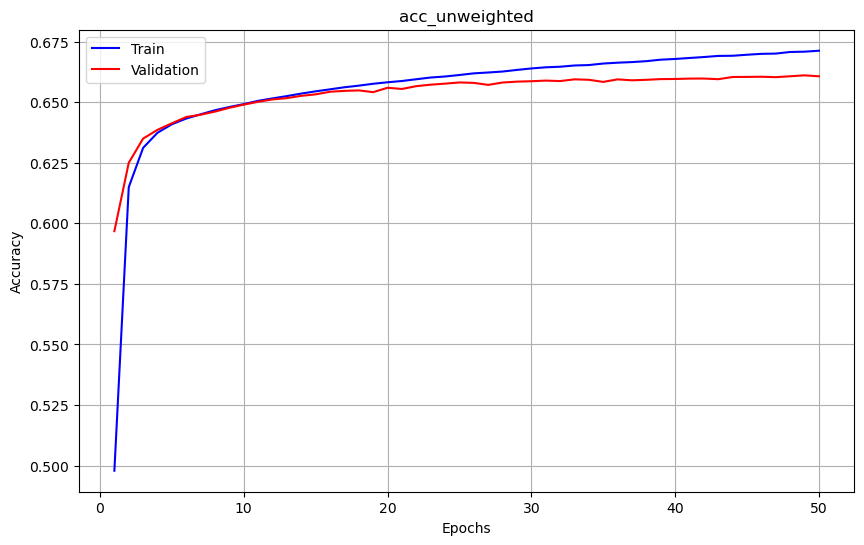

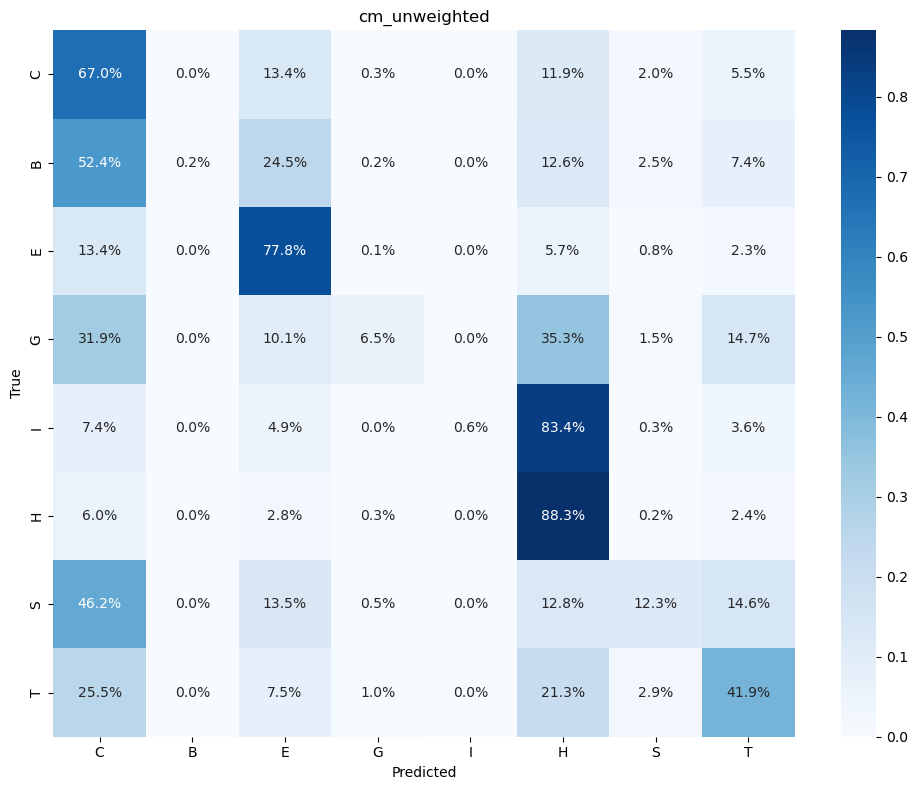

              precision    recall  f1-score   support

           C       0.57      0.67      0.62     64930
           B       0.55      0.00      0.00      2437
           E       0.71      0.78      0.74     55367
           G       0.43      0.06      0.11      9621
           I       0.67      0.01      0.01      1436
           H       0.75      0.88      0.81     82838
           S       0.46      0.12      0.19     19850
           T       0.50      0.42      0.45     26728

    accuracy                           0.66    263207
   macro avg       0.58      0.37      0.37    263207
weighted avg       0.64      0.66      0.63    263207



In [39]:
train_losses, train_accs, val_losses, val_accs, model = experiment(train_loader, val_loader, weighted_loss=False, dropout=0.5)

In [40]:
def eval_on_test(data_loader, model, class_names=SS8_VOCAB):
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for X, y, mask in tqdm(data_loader, leave=False):
            X = X.to(device=device, dtype=torch.float32)
            y = y.to(device=device, dtype=torch.long)
            mask = mask.to(device=device, dtype=torch.bool)

            y_hat = model.forward(X)
            pred = y_hat.argmax(dim=-1).to(dtype=torch.long)

            all_preds.append(pred[mask].cpu())
            all_labels.append(y[mask].cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    print(classification_report(all_labels, all_preds, target_names=class_names))

In [41]:
eval_on_test(test_loader, model)

              precision    recall  f1-score   support

           C       0.49      0.63      0.55     32637
           B       0.20      0.00      0.00      1819
           E       0.67      0.74      0.70     29752
           G       0.39      0.05      0.09      5152
           I       0.72      0.02      0.03       776
           H       0.74      0.87      0.80     42361
           S       0.44      0.10      0.16     13373
           T       0.47      0.40      0.43     16234

    accuracy                           0.62    142104
   macro avg       0.51      0.35      0.35    142104
weighted avg       0.59      0.62      0.58    142104

